# Predicting Football Match Scores Using In-Match Performance Metrics

### During a football match, performance metrics such as shots on target, goal attempts, possession, and goalkeeper saves are continuously recorded and updated. This project investigates how these in-match statistics can be used to estimate the final score and predict the likely winner using a Multiple Linear Regression model.

### The dataset used in this project contains only full-time match statistics rather than time-stamped statistics collected throughout different stages of a match. Consequently, the model was trained using complete match statistics as a proof of concept. The methodology demonstrates how in-match performance metrics relate to the final score. With access to live or halftime statistics, the same modelling approach could be extended to support real-time score prediction.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\taiba\OneDrive\Desktop\Project\Football.csv")

C:\Users\taiba\AppData\Local\Temp\ipykernel_16700\565557701.py:1: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\taiba\OneDrive\Desktop\Project\Football.csv")


In [3]:
df.head()

,Country,League,home_team,away_team,home_score,away_score,Date_day,Date_hour,Ball_Possession_Home,Ball_Possession_Host,...,Goalkeeper_Saves_Host,Fouls_Home,Fouls_Host,Total_Passes_Home,Total_Passes_Host,Completed_Passes_Home,Completed_Passes_Host,Attacks_Home,Attacks_Host,Winner
0,Germany,Bundesliga,B. Monchengladbach,Werder Bremen,4,1,3.11,19:30,47%,53%,...,4.0,12.0,10.0,479.0,549.0,395.0,453.0,NaN,NaN,B. Monchengladbach
1,Germany,Bundesliga,Freiburg,Mainz,0,0,3.11,17:30,51%,49%,...,2.0,9.0,12.0,471.0,443.0,377.0,362.0,NaN,NaN,Draw
2,Germany,Bundesliga,Dortmund,RB Leipzig,2,1,2.11,20:30,56%,44%,...,5.0,11.0,12.0,528.0,418.0,424.0,321.0,NaN,NaN,Dortmund
3,Germany,Bundesliga,Bayern Munich,Union Berlin,3,0,2.11,17:30,77%,23%,...,4.0,2.0,9.0,866.0,244.0,794.0,169.0,NaN,NaN,Bayern Munich
4,Germany,Bundesliga,Eintracht Frankfurt,Bochum,7,2,2.11,17:30,65%,35%,...,2.0,6.0,15.0,594.0,324.0,500.0,223.0,NaN,NaN,Eintracht Frankfurt


In [4]:
df.shape

(95384, 31)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95384 entries, 0 to 95383
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country                95384 non-null  object 
 1   League                 95384 non-null  object 
 2   home_team              95384 non-null  object 
 3   away_team              95384 non-null  object 
 4   home_score             95384 non-null  object 
 5   away_score             95384 non-null  object 
 6   Date_day               95384 non-null  float64
 7   Date_hour              95384 non-null  object 
 8   Ball_Possession_Home   37721 non-null  object 
 9   Ball_Possession_Host   37721 non-null  object 
 10  Goal_Attempts_Home     38453 non-null  float64
 11  Goal_Attempts_Host     38453 non-null  float64
 12  Shots_on_Goal_Home     38449 non-null  float64
 13  Shots_on_Goal_Host     38449 non-null  float64
 14  Shots_off_Goal_Home    38390 non-null  float64
 15  Sh

## DATA CLEANING

In [6]:
df.describe(include="all")

,Country,League,home_team,away_team,home_score,away_score,Date_day,Date_hour,Ball_Possession_Home,Ball_Possession_Host,...,Goalkeeper_Saves_Host,Fouls_Home,Fouls_Host,Total_Passes_Home,Total_Passes_Host,Completed_Passes_Home,Completed_Passes_Host,Attacks_Home,Attacks_Host,Winner
count,95384,95384,95384,95384,95384,95384,95384.000000,95384,37721,37721,...,38453.000000,35873.000000,35873.000000,11649.000000,11649.000000,6568.000000,6568.000000,13512.000000,13512.000000,95384
unique,6,18,2518,2141,25,26,NaN,125,72,72,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1715
top,England,Championship,Juventus,Sampdoria,1,1,NaN,17:00,52%,48%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Draw
freq,26107,9854,517,502,21177,22376,NaN,16564,1634,1634,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23275
mean,NaN,NaN,NaN,NaN,NaN,NaN,15.621889,NaN,NaN,NaN,...,3.401685,12.746690,13.118167,445.735428,427.552322,356.180725,338.466657,105.649793,99.285524,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,8.773724,NaN,NaN,NaN,...,2.241247,4.283345,4.473607,133.644392,123.790858,126.674939,121.725349,28.016961,26.890230,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,1.010000,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,8.040000,NaN,NaN,NaN,...,2.000000,10.000000,10.000000,353.000000,339.000000,264.000000,249.000000,88.000000,83.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,16.030000,NaN,NaN,NaN,...,3.000000,12.000000,13.000000,432.000000,413.000000,343.000000,324.000000,106.000000,99.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,23.040000,NaN,NaN,NaN,...,5.000000,15.000000,16.000000,525.000000,503.000000,432.250000,414.000000,123.000000,116.000000,NaN


In [7]:
df.isnull().sum()

Country                      0
League                       0
home_team                    0
away_team                    0
home_score                   0
away_score                   0
Date_day                     0
Date_hour                    0
Ball_Possession_Home     57663
Ball_Possession_Host     57663
Goal_Attempts_Home       56931
Goal_Attempts_Host       56931
Shots_on_Goal_Home       56935
Shots_on_Goal_Host       56935
Shots_off_Goal_Home      56994
Shots_off_Goal_Host      56994
Free_Kicks_Home          65615
Free_Kicks_Host          65615
Offsides_Home            58652
Offsides_Host            58652
Goalkeeper_Saves_Home    56931
Goalkeeper_Saves_Host    56931
Fouls_Home               59511
Fouls_Host               59511
Total_Passes_Home        83735
Total_Passes_Host        83735
Completed_Passes_Home    88816
Completed_Passes_Host    88816
Attacks_Home             81872
Attacks_Host             81872
Winner                       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(44)

In [9]:
df=df.drop_duplicates()

In [10]:
df.shape


(95340, 31)

In [11]:
clean_df=df.dropna()
clean_df

,Country,League,home_team,away_team,home_score,away_score,Date_day,Date_hour,Ball_Possession_Home,Ball_Possession_Host,...,Goalkeeper_Saves_Host,Fouls_Home,Fouls_Host,Total_Passes_Home,Total_Passes_Host,Completed_Passes_Home,Completed_Passes_Host,Attacks_Home,Attacks_Host,Winner
54,Germany,Bundesliga,Mainz,Werder Bremen,1,2,15.09,18:30,55%,45%,...,4.0,12.0,7.0,481.0,347.0,390.0,271.0,119.0,62.0,Werder Bremen
55,Germany,Bundesliga,Augsburg,St. Pauli,3,1,15.09,16:30,44%,56%,...,7.0,12.0,10.0,317.0,424.0,235.0,335.0,72.0,107.0,Augsburg
56,Germany,Bundesliga,Holstein Kiel,Bayern Munich,1,6,14.09,19:30,36%,64%,...,0.0,12.0,11.0,337.0,811.0,263.0,746.0,54.0,145.0,Bayern Munich
57,Germany,Bundesliga,B. Monchengladbach,Stuttgart,1,3,14.09,16:30,52%,48%,...,6.0,14.0,12.0,402.0,534.0,318.0,449.0,96.0,108.0,Stuttgart
58,Germany,Bundesliga,Freiburg,Bochum,2,1,14.09,16:30,64%,36%,...,7.0,5.0,16.0,437.0,367.0,345.0,264.0,92.0,116.0,Freiburg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57171,England,Fa-cup,Ipswich,Barrow,0,0,4.12,18:00,53%,47%,...,2.0,15.0,5.0,426.0,380.0,300.0,251.0,99.0,89.0,Draw
57176,England,Fa-cup,Buxton,Morecambe,0,1,4.12,15:45,46%,54%,...,1.0,11.0,11.0,311.0,368.0,191.0,264.0,83.0,84.0,Morecambe
57177,England,Fa-cup,Gateshead,Charlton,0,2,3.12,22:45,47%,53%,...,5.0,12.0,10.0,373.0,407.0,246.0,300.0,61.0,158.0,Charlton
57191,England,Fa-cup,Dag & Red,Salford,0,1,8.11,22:45,52%,48%,...,9.0,11.0,18.0,391.0,389.0,274.0,263.0,98.0,98.0,Salford


#### We are only left with 5640 rows after dropping the rows that contain any missing values, meaning we loose 95% of the data. Hence this dataset cannot be used.  

In [12]:
df=df.drop(columns=['Total_Passes_Home',
    'Total_Passes_Host',
    'Completed_Passes_Home',
    'Completed_Passes_Host',
    'Attacks_Home',
    'Attacks_Host'])

In [13]:
df.shape

(95340, 25)

In [14]:
df.isnull().sum()

Country                      0
League                       0
home_team                    0
away_team                    0
home_score                   0
away_score                   0
Date_day                     0
Date_hour                    0
Ball_Possession_Home     57653
Ball_Possession_Host     57653
Goal_Attempts_Home       56921
Goal_Attempts_Host       56921
Shots_on_Goal_Home       56925
Shots_on_Goal_Host       56925
Shots_off_Goal_Home      56984
Shots_off_Goal_Host      56984
Free_Kicks_Home          65596
Free_Kicks_Host          65596
Offsides_Home            58642
Offsides_Host            58642
Goalkeeper_Saves_Home    56921
Goalkeeper_Saves_Host    56921
Fouls_Home               59501
Fouls_Host               59501
Winner                       0
dtype: int64

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95340 entries, 0 to 95383
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country                95340 non-null  object 
 1   League                 95340 non-null  object 
 2   home_team              95340 non-null  object 
 3   away_team              95340 non-null  object 
 4   home_score             95340 non-null  object 
 5   away_score             95340 non-null  object 
 6   Date_day               95340 non-null  float64
 7   Date_hour              95340 non-null  object 
 8   Ball_Possession_Home   37687 non-null  object 
 9   Ball_Possession_Host   37687 non-null  object 
 10  Goal_Attempts_Home     38419 non-null  float64
 11  Goal_Attempts_Host     38419 non-null  float64
 12  Shots_on_Goal_Home     38415 non-null  float64
 13  Shots_on_Goal_Host     38415 non-null  float64
 14  Shots_off_Goal_Home    38356 non-null  float64
 15  Shots_o

In [16]:
df.dropna().shape

(26632, 25)

In [17]:
df['home_score'] = pd.to_numeric(df['home_score'], errors='coerce')
df['away_score'] = pd.to_numeric(df['away_score'], errors='coerce')

In [18]:
df[['home_score', 'away_score']].dtypes

home_score    float64
away_score    float64
dtype: object

In [19]:
clean_df = df.dropna().copy()

In [20]:
clean_df.isnull().sum()

Country                  0
League                   0
home_team                0
away_team                0
home_score               0
away_score               0
Date_day                 0
Date_hour                0
Ball_Possession_Home     0
Ball_Possession_Host     0
Goal_Attempts_Home       0
Goal_Attempts_Host       0
Shots_on_Goal_Home       0
Shots_on_Goal_Host       0
Shots_off_Goal_Home      0
Shots_off_Goal_Host      0
Free_Kicks_Home          0
Free_Kicks_Host          0
Offsides_Home            0
Offsides_Host            0
Goalkeeper_Saves_Home    0
Goalkeeper_Saves_Host    0
Fouls_Home               0
Fouls_Host               0
Winner                   0
dtype: int64

# Exploratory Data Analysis (EDA)

In [21]:
clean_df['Match_Result'] = clean_df.apply(
    lambda row: 'Home Win' if row['Winner'] == row['home_team']
    else ('Away Win' if row['Winner'] == row['away_team']
    else 'Draw'),
    axis=1
)

In [22]:
clean_df.head(5)

,Country,League,home_team,away_team,home_score,away_score,Date_day,Date_hour,Ball_Possession_Home,Ball_Possession_Host,...,Free_Kicks_Home,Free_Kicks_Host,Offsides_Home,Offsides_Host,Goalkeeper_Saves_Home,Goalkeeper_Saves_Host,Fouls_Home,Fouls_Host,Winner,Match_Result
0,Germany,Bundesliga,B. Monchengladbach,Werder Bremen,4.0,1.0,3.11,19:30,47%,53%,...,10.0,12.0,2.0,1.0,4.0,4.0,12.0,10.0,B. Monchengladbach,Home Win
1,Germany,Bundesliga,Freiburg,Mainz,0.0,0.0,3.11,17:30,51%,49%,...,12.0,9.0,2.0,2.0,2.0,2.0,9.0,12.0,Draw,Draw
2,Germany,Bundesliga,Dortmund,RB Leipzig,2.0,1.0,2.11,20:30,56%,44%,...,12.0,11.0,2.0,2.0,2.0,5.0,11.0,12.0,Dortmund,Home Win
3,Germany,Bundesliga,Bayern Munich,Union Berlin,3.0,0.0,2.11,17:30,77%,23%,...,9.0,2.0,1.0,3.0,1.0,4.0,2.0,9.0,Bayern Munich,Home Win
4,Germany,Bundesliga,Eintracht Frankfurt,Bochum,7.0,2.0,2.11,17:30,65%,35%,...,15.0,6.0,0.0,1.0,6.0,2.0,6.0,15.0,Eintracht Frankfurt,Home Win


# VISUALIZATION

## Q1 Does playing at home increase the chances of winning?

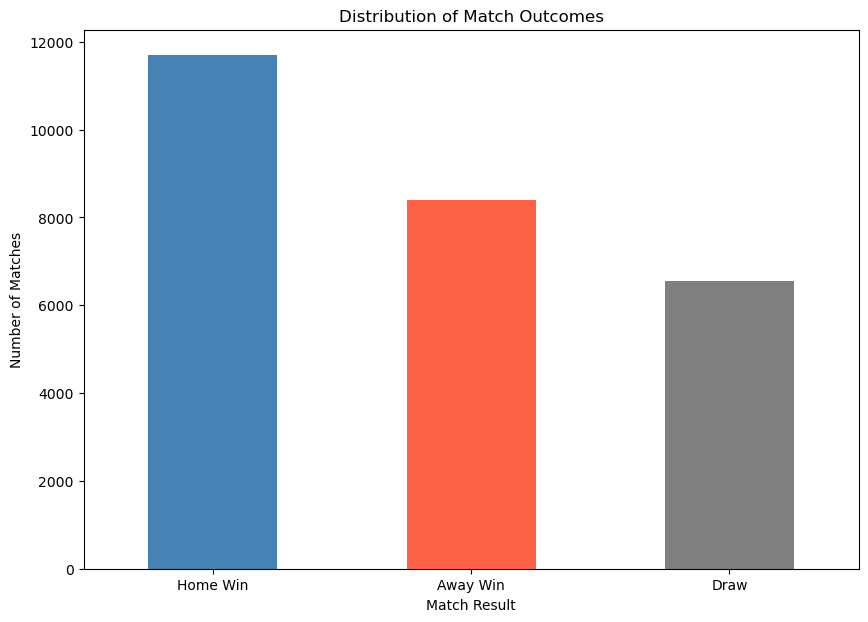

In [23]:
import matplotlib.pyplot as plt

match_result = clean_df['Match_Result'].value_counts()

plt.figure(figsize=(10,7))
match_result.plot(kind='bar', color=['steelblue', 'tomato', 'gray'])

plt.title('Distribution of Match Outcomes')
plt.xlabel('Match Result')
plt.ylabel('Number of Matches')
plt.xticks(rotation=0)

plt.show()

#### Observation: Home wins occur more frequently than away wins and draws in the dataset.

#### Interpretation: This suggests that teams playing at home may benefit from a home advantage, potentially due to familiar playing conditions, crowd support, and reduced travel fatigue.

#### Conclusion: Since home teams win more often, the home venue appears to have an influence on match outcomes and should be considered when interpreting the predictive model.

## Q2 Do home teams maintain higher average ball possession than away teams?

In [24]:
clean_df[['Ball_Possession_Home', 'Ball_Possession_Host']].dtypes

Ball_Possession_Home    object
Ball_Possession_Host    object
dtype: object

In [25]:
clean_df['Ball_Possession_Home'] = (
    clean_df['Ball_Possession_Home']
    .str.replace('%', '', regex=False)
    .astype(float)
)

clean_df['Ball_Possession_Host'] = (
    clean_df['Ball_Possession_Host']
    .str.replace('%', '', regex=False)
    .astype(float)
)

In [26]:
home_avg_possession = clean_df['Ball_Possession_Home'].mean()
away_avg_possession = clean_df['Ball_Possession_Host'].mean()

print("Average Home Possession:", home_avg_possession)
print("Average Away Possession:", away_avg_possession)

Average Home Possession: 51.09289576449384
Average Away Possession: 48.90729197957344


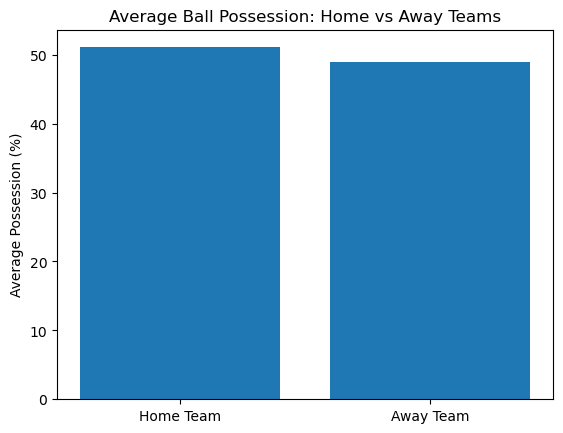

In [27]:
import matplotlib.pyplot as plt

plt.bar(
    ['Home Team', 'Away Team'],
    [home_avg_possession, away_avg_possession]
)

plt.title('Average Ball Possession: Home vs Away Teams')
plt.ylabel('Average Possession (%)')
plt.show()

#### Observation: Home teams recorded an average possession of approximately 51%, while away teams averaged approximately 48%.
#### Interpretation: Home teams generally controlled possession slightly more than away teams. However, the difference is relat ively small, suggesting that possession alone may not account for the higher number of home wins observed in the dataset.

In [28]:
clean_df['Winner_Possession'] = clean_df.apply(
    lambda row: row['Ball_Possession_Home']
    if row['Match_Result'] == 'Home Win'
    else row['Ball_Possession_Host']
    if row['Match_Result'] == 'Away Win'
    else None,
    axis=1
)

clean_df['Loser_Possession'] = clean_df.apply(
    lambda row: row['Ball_Possession_Host']
    if row['Match_Result'] == 'Home Win'
    else row['Ball_Possession_Home']
    if row['Match_Result'] == 'Away Win'
    else None,
    axis=1
)

In [29]:
winner_avg_possession = clean_df['Winner_Possession'].mean()
loser_avg_possession = clean_df['Loser_Possession'].mean()

print("Winning Team Average Possession:", winner_avg_possession)
print("Losing Team Average Possession:", loser_avg_possession)

Winning Team Average Possession: 51.13348269853124
Losing Team Average Possession: 48.86666666666667


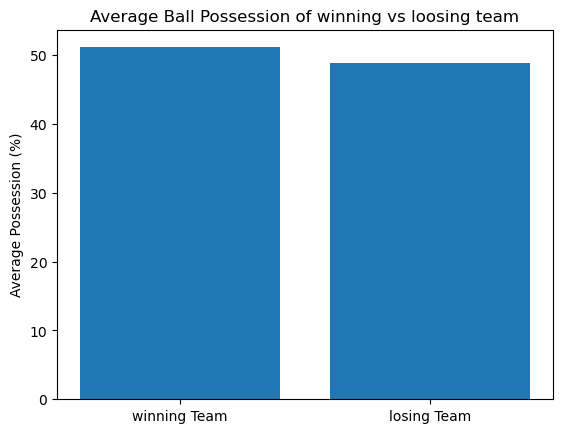

In [30]:
plt.bar(
    ['winning Team', 'losing Team'],
    [winner_avg_possession, loser_avg_possession])

plt.title('Average Ball Possession of winning vs loosing team')
plt.ylabel('Average Possession (%)')
plt.show()

In [31]:
# Standard Deviation of ball possession

home_std = clean_df['Ball_Possession_Home'].std()
away_std = clean_df['Ball_Possession_Host'].std()

print("Standard Deviation of Home Team Possession:", home_std)
print("Standard Deviation of Away Team Possession:", away_std)

Standard Deviation of Home Team Possession: 10.278079765006552
Standard Deviation of Away Team Possession: 10.278021178504412


#### Therefore, there is not much difference between the average possessions of winning/loosing teams and those of home and away teams. I would conclude that possession can be used as a minor factor when furthur building the actual model.  

## Q3 Do teams with more shots on target win more matches?

In [32]:
# Winner Shots on Target
clean_df['Winner_Shots_on_Target'] = clean_df.apply(
    lambda row: row['Shots_on_Goal_Home']
    if row['Match_Result'] == 'Home Win'
    else row['Shots_on_Goal_Host']
    if row['Match_Result'] == 'Away Win'
    else None,
    axis=1
)

# Loser Shots on Target
clean_df['Loser_Shots_on_Target'] = clean_df.apply(
    lambda row: row['Shots_on_Goal_Host']
    if row['Match_Result'] == 'Home Win'
    else row['Shots_on_Goal_Home']
    if row['Match_Result'] == 'Away Win'
    else None,
    axis=1
)
winner_avg_shots = clean_df['Winner_Shots_on_Target'].mean()
loser_avg_shots = clean_df['Loser_Shots_on_Target'].mean()

print("Winner Average Shots on Target:", winner_avg_shots)
print("Loser Average Shots on Target:", loser_avg_shots)

Winner Average Shots on Target: 5.761762509335325
Loser Average Shots on Target: 3.536420214090117


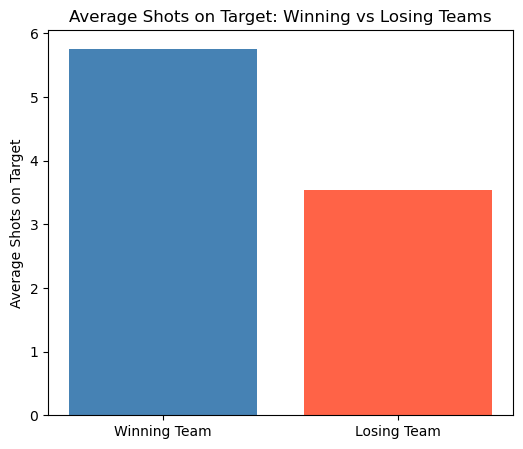

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.bar(
    ['Winning Team', 'Losing Team'],
    [winner_avg_shots, loser_avg_shots],
    color=['steelblue', 'tomato']
)

plt.title('Average Shots on Target: Winning vs Losing Teams')
plt.ylabel('Average Shots on Target')

plt.show()

## Q3 Do teams with more goal attempts win more matches?

In [34]:
clean_df['Winner_Goal_Attempts'] = clean_df.apply(
    lambda row: row['Goal_Attempts_Home']
    if row['Match_Result'] == 'Home Win'
    else row['Goal_Attempts_Host']
    if row['Match_Result'] == 'Away Win'
    else None,
    axis=1
)

clean_df['Loser_Goal_Attempts'] = clean_df.apply(
    lambda row: row['Goal_Attempts_Host']
    if row['Match_Result'] == 'Home Win'
    else row['Goal_Attempts_Home']
    if row['Match_Result'] == 'Away Win'
    else None,
    axis=1
)

In [35]:
winner_avg = clean_df['Winner_Goal_Attempts'].mean()
loser_avg = clean_df['Loser_Goal_Attempts'].mean()

print(winner_avg)
print(loser_avg)

13.657903908389345
11.156733881005726


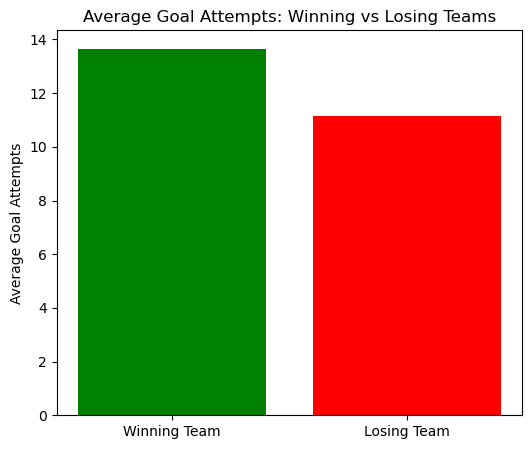

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.bar(
    ['Winning Team', 'Losing Team'],
    [winner_avg, loser_avg],
    color=['green', 'red']
)

plt.title('Average Goal Attempts: Winning vs Losing Teams')
plt.ylabel('Average Goal Attempts')

plt.show()

#### Winning teams consistently generated more goal attempts than losing teams. This suggests that creating more attacking opportunities is associated with a higher probability of winning. The difference is also more pronounced than the difference observed in ball possession, indicating that attacking intent may be a stronger indicator of success than simply controlling possession.

## EDA with the rest of the metrics

In [37]:
# Winner Free Kicks
clean_df['Winner_Free_Kicks'] = clean_df.apply(
    lambda row: row['Free_Kicks_Home']
    if row['Match_Result'] == 'Home Win'
    else row['Free_Kicks_Host']
    if row['Match_Result'] == 'Away Win'
    else None,
    axis=1
)

# Loser Free Kicks
clean_df['Loser_Free_Kicks'] = clean_df.apply(
    lambda row: row['Free_Kicks_Host']
    if row['Match_Result'] == 'Home Win'
    else row['Free_Kicks_Home']
    if row['Match_Result'] == 'Away Win'
    else None,
    axis=1
)

# Winner Offsides
clean_df['Winner_Offsides'] = clean_df.apply(
    lambda row: row['Offsides_Home']
    if row['Match_Result'] == 'Home Win'
    else row['Offsides_Host']
    if row['Match_Result'] == 'Away Win'
    else None,
    axis=1
)

# Loser Offsides
clean_df['Loser_Offsides'] = clean_df.apply(
    lambda row: row['Offsides_Host']
    if row['Match_Result'] == 'Home Win'
    else row['Offsides_Home']
    if row['Match_Result'] == 'Away Win'
    else None,
    axis=1
)

# Winner Goalkeeper Saves
clean_df['Winner_Goalkeeper_Saves'] = clean_df.apply(
    lambda row: row['Goalkeeper_Saves_Home']
    if row['Match_Result'] == 'Home Win'
    else row['Goalkeeper_Saves_Host']
    if row['Match_Result'] == 'Away Win'
    else None,
    axis=1
)

# Loser Goalkeeper Saves
clean_df['Loser_Goalkeeper_Saves'] = clean_df.apply(
    lambda row: row['Goalkeeper_Saves_Host']
    if row['Match_Result'] == 'Home Win'
    else row['Goalkeeper_Saves_Home']
    if row['Match_Result'] == 'Away Win'
    else None,
    axis=1
)

# Winner Fouls
clean_df['Winner_Fouls'] = clean_df.apply(
    lambda row: row['Fouls_Home']
    if row['Match_Result'] == 'Home Win'
    else row['Fouls_Host']
    if row['Match_Result'] == 'Away Win'
    else None,
    axis=1
)

# Loser Fouls
clean_df['Loser_Fouls'] = clean_df.apply(
    lambda row: row['Fouls_Host']
    if row['Match_Result'] == 'Home Win'
    else row['Fouls_Home']
    if row['Match_Result'] == 'Away Win'
    else None,
    axis=1
)

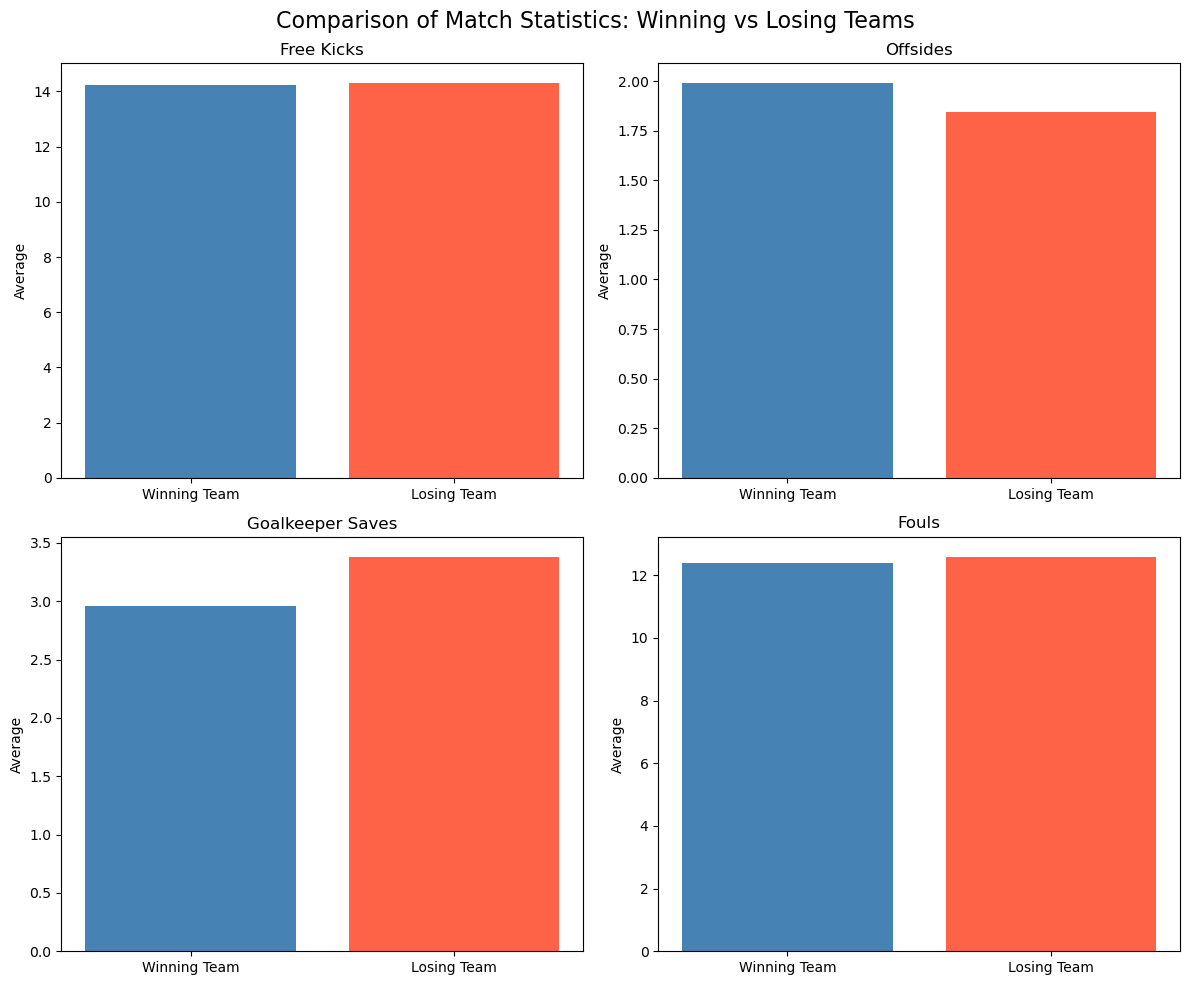

In [38]:
# Calculate averages
winner_stats = [
    clean_df['Winner_Free_Kicks'].mean(),
    clean_df['Winner_Offsides'].mean(),
    clean_df['Winner_Goalkeeper_Saves'].mean(),
    clean_df['Winner_Fouls'].mean()
]

loser_stats = [
    clean_df['Loser_Free_Kicks'].mean(),
    clean_df['Loser_Offsides'].mean(),
    clean_df['Loser_Goalkeeper_Saves'].mean(),
    clean_df['Loser_Fouls'].mean()
]

titles = [
    "Free Kicks",
    "Offsides",
    "Goalkeeper Saves",
    "Fouls"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, ax in enumerate(axes.flat):
    ax.bar(
        ['Winning Team', 'Losing Team'],
        [winner_stats[i], loser_stats[i]],
        color=['steelblue', 'tomato']
    )
    ax.set_title(titles[i])
    ax.set_ylabel('Average')

plt.suptitle('Comparison of Match Statistics: Winning vs Losing Teams', fontsize=16)

plt.tight_layout()
plt.show()

#### Winning teams showed slightly higher offsides, indicating greater attacking intent.
#### Losing teams recorded more goalkeeper saves, suggesting they faced more attacking pressure.
#### Free kicks and fouls showed minimal differences between winning and losing teams.
#### Overall, attacking metrics are more useful predictors of match outcomes than defensive or disciplinary metrics.

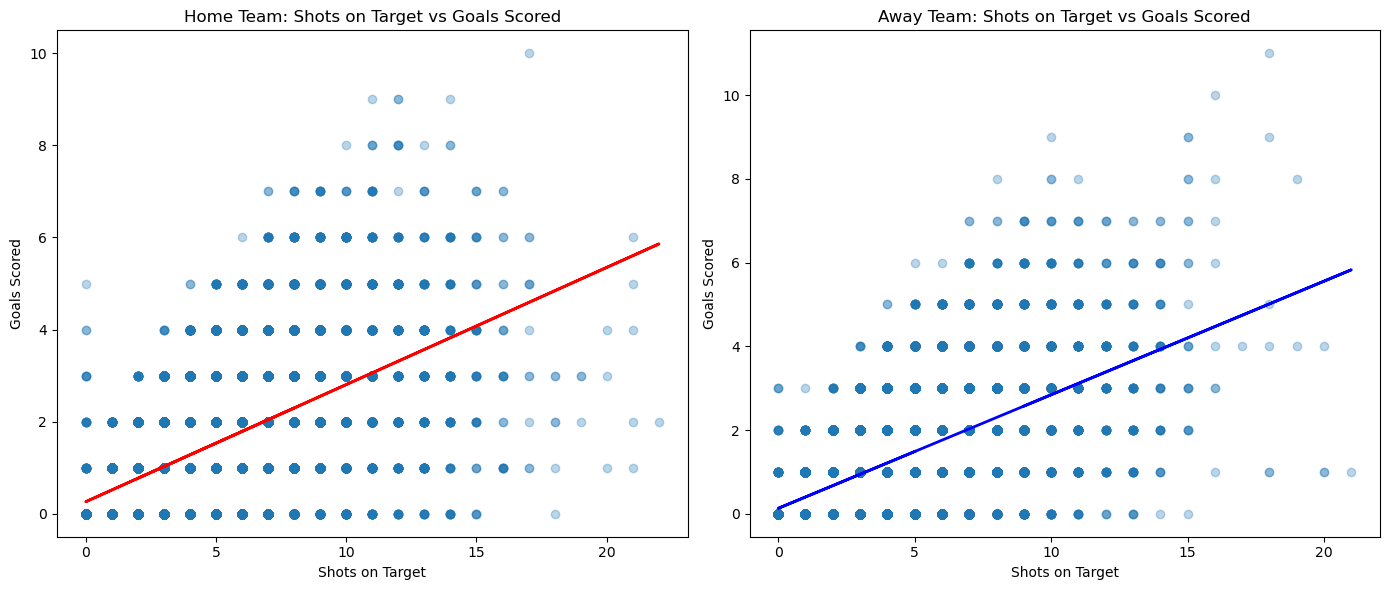

In [39]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Home
axes[0].scatter(clean_df['Shots_on_Goal_Home'], clean_df['home_score'], alpha=0.3)
m, b = np.polyfit(clean_df['Shots_on_Goal_Home'], clean_df['home_score'], 1)
axes[0].plot(clean_df['Shots_on_Goal_Home'],
             m*clean_df['Shots_on_Goal_Home'] + b,
             color='red', linewidth=2)
axes[0].set_title('Home Team: Shots on Target vs Goals Scored')
axes[0].set_xlabel('Shots on Target')
axes[0].set_ylabel('Goals Scored')

# Away
axes[1].scatter(clean_df['Shots_on_Goal_Host'], clean_df['away_score'], alpha=0.3)
m, b = np.polyfit(clean_df['Shots_on_Goal_Host'], clean_df['away_score'], 1)
axes[1].plot(clean_df['Shots_on_Goal_Host'],
             m*clean_df['Shots_on_Goal_Host'] + b,
             color='blue', linewidth=2)
axes[1].set_title('Away Team: Shots on Target vs Goals Scored')
axes[1].set_xlabel('Shots on Target')
axes[1].set_ylabel('Goals Scored')

plt.tight_layout()
plt.show()

#### As the number of shots on target increases, the number of goals scored generally increases for both home and away teams.
#### While there is some variation, teams with higher shots on target tend to score more goals.

# MODEL BUILDING

In [40]:
clean_df=clean_df.drop(columns=['Winner_Possession', 'Loser_Possession',
       'Winner_Goal_Attempts', 'Loser_Goal_Attempts', 'Winner_Free_Kicks',
       'Loser_Free_Kicks', 'Winner_Offsides', 'Loser_Offsides',
       'Winner_Goalkeeper_Saves', 'Loser_Goalkeeper_Saves', 'Winner_Fouls',
       'Loser_Fouls', 'Winner_Shots_on_Target', 'Loser_Shots_on_Target'])

In [41]:
clean_df.columns

Index(['Country', 'League', 'home_team', 'away_team', 'home_score',
       'away_score', 'Date_day', 'Date_hour', 'Ball_Possession_Home',
       'Ball_Possession_Host', 'Goal_Attempts_Home', 'Goal_Attempts_Host',
       'Shots_on_Goal_Home', 'Shots_on_Goal_Host', 'Shots_off_Goal_Home',
       'Shots_off_Goal_Host', 'Free_Kicks_Home', 'Free_Kicks_Host',
       'Offsides_Home', 'Offsides_Host', 'Goalkeeper_Saves_Home',
       'Goalkeeper_Saves_Host', 'Fouls_Home', 'Fouls_Host', 'Winner',
       'Match_Result'],
      dtype='object')

In [42]:
# defining independent variables
X=clean_df[['Ball_Possession_Home',
       'Ball_Possession_Host', 'Goal_Attempts_Home', 'Goal_Attempts_Host',
       'Shots_on_Goal_Home', 'Shots_on_Goal_Host', 'Shots_off_Goal_Home',
       'Shots_off_Goal_Host', 'Free_Kicks_Home', 'Free_Kicks_Host',
       'Offsides_Home', 'Offsides_Host', 'Goalkeeper_Saves_Home',
       'Goalkeeper_Saves_Host', 'Fouls_Home', 'Fouls_Host']]

In [43]:
# defining dependent variables
y = clean_df[['home_score', 'away_score']]

In [44]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

In [45]:
vif = pd.DataFrame()

vif["Feature"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)

                  Feature        VIF
0    Ball_Possession_Home  20.385386
1    Ball_Possession_Host  18.858285
2      Goal_Attempts_Home  43.617609
3      Goal_Attempts_Host  39.875745
4      Shots_on_Goal_Home  25.215576
5      Shots_on_Goal_Host  22.474230
6     Shots_off_Goal_Home  14.902078
7     Shots_off_Goal_Host  13.842972
8         Free_Kicks_Home  60.610402
9         Free_Kicks_Host  65.522478
10          Offsides_Home   4.183666
11          Offsides_Host   3.692057
12  Goalkeeper_Saves_Home  13.371095
13  Goalkeeper_Saves_Host  15.222010
14             Fouls_Home  54.537605
15             Fouls_Host  52.121016


#### What this shows is that many of the independent variables, i.e. predictors, are highly correlated with each other. 
#### So it is better to remove a few features which basically overlap in the information that they provide.

In [46]:
X=X.drop(columns=['Shots_off_Goal_Home','Shots_off_Goal_Host','Free_Kicks_Host','Fouls_Host','Fouls_Home', 'Free_Kicks_Home','Offsides_Home','Offsides_Host'])

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42
)
print(X_train.shape)

(23968, 8)


In [48]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame()

vif["Feature"] = X_train.columns
vif["VIF"] = [
    variance_inflation_factor(X_train.values, i)
    for i in range(X_train.shape[1])
]

print(vif)

                 Feature        VIF
0   Ball_Possession_Home  14.317907
1   Ball_Possession_Host  12.844943
2     Goal_Attempts_Home  15.500693
3     Goal_Attempts_Host  13.457910
4     Shots_on_Goal_Home  21.117127
5     Shots_on_Goal_Host  18.555849
6  Goalkeeper_Saves_Home  13.307368
7  Goalkeeper_Saves_Host  14.951910


## Model Implementation

In [49]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [50]:
y_pred=model.predict(X_test)

In [51]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

In [52]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

r2= r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("R² Score:", r2)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

R² Score: 0.9886818199212615
Mean Absolute Error: 0.029757679881213042
Root Mean Squared Error: 0.13043560732137466


In [53]:
print("Home Score R²:",
      r2_score(y_test['home_score'], y_pred[:,0]))

print("Away Score R²:",
      r2_score(y_test['away_score'], y_pred[:,1]))

Home Score R²: 0.9892585536691824
Away Score R²: 0.9881050861733406


In [54]:
comparison = pd.DataFrame({
    'Actual_Home': y_test['home_score'].values,
    'Predicted_Home': y_pred[:,0],
    'Actual_Away': y_test['away_score'].values,
    'Predicted_Away': y_pred[:,1]
})

comparison.head(20)

,Actual_Home,Predicted_Home,Actual_Away,Predicted_Away
0,1.0,1.020469,1.0,1.022465
1,2.0,2.011445,1.0,1.012548
2,3.0,3.018096,1.0,1.019149
3,2.0,2.007967,2.0,2.018982
4,3.0,3.004647,2.0,2.006192
5,0.0,0.021429,1.0,1.017967
6,0.0,0.022455,1.0,1.020884
7,0.0,0.009092,0.0,0.021369
8,2.0,2.026773,0.0,0.019004
9,0.0,0.019794,1.0,1.021275


In [55]:
print(X.columns.tolist())

['Ball_Possession_Home', 'Ball_Possession_Host', 'Goal_Attempts_Home', 'Goal_Attempts_Host', 'Shots_on_Goal_Home', 'Shots_on_Goal_Host', 'Goalkeeper_Saves_Home', 'Goalkeeper_Saves_Host']


#### Thinking practically, the problem is that it is not easy to provide all the independent metrics during the match in order to build the model. 
#### Hence, I would go ahead by analysing several new models that use fewer or more easily available metrics.

In [56]:
X.columns

Index(['Ball_Possession_Home', 'Ball_Possession_Host', 'Goal_Attempts_Home',
       'Goal_Attempts_Host', 'Shots_on_Goal_Home', 'Shots_on_Goal_Host',
       'Goalkeeper_Saves_Home', 'Goalkeeper_Saves_Host'],
      dtype='object')

## Using possession metrics only

In [57]:
possession=X[['Ball_Possession_Home', 'Ball_Possession_Host']]
X_train, X_test, y_train, y_test= train_test_split(possession, y, test_size=0.1, random_state=42)
model.fit(X_train, y_train)
y_pred_possession= model.predict(X_test)
r2= r2_score(y_test, y_pred_possession)
print("R² Score:", r2)

R² Score: 0.015142497635904473


In [58]:
print(X_train.shape)

(23968, 2)


In [59]:
X_train.head(2)

,Ball_Possession_Home,Ball_Possession_Host
12482,52.0,48.0
47328,63.0,37.0


## Using Goal attempts only 

In [60]:
goal_attempts=X[['Goal_Attempts_Home','Goal_Attempts_Host']]
X_train, X_test, y_train, y_test= train_test_split(goal_attempts, y, test_size=0.1, random_state=42)
model.fit(X_train, y_train)
y_pred_goal_attempts= model.predict(X_test)
r2= r2_score(y_test, y_pred_goal_attempts)
print("R² Score:", r2)

R² Score: 0.09415476061550437


In [61]:
print(X_train.shape)

(23968, 2)


In [62]:
X_train.head()

,Goal_Attempts_Home,Goal_Attempts_Host
12482,16.0,12.0
47328,24.0,7.0
490,13.0,10.0
64106,11.0,10.0
20285,11.0,5.0


## Using possession and attempts both 

In [63]:
possession_attempts=X[['Ball_Possession_Home', 'Ball_Possession_Host', 'Goal_Attempts_Home','Goal_Attempts_Host' ]]
X_train, X_test, y_train, y_test= train_test_split(possession_attempts, y, test_size=0.1, random_state=42)
model.fit(X_train, y_train)
y_pred_possession_attempts= model.predict(X_test)
r2= r2_score(y_test, y_pred_possession_attempts)
print("R² Score:", r2)

R² Score: 0.09450246904726062


## Using possession, goal attempts and shots on target

In [64]:
three_metrics=X[['Ball_Possession_Home', 'Ball_Possession_Host', 'Goal_Attempts_Home','Goal_Attempts_Host','Shots_on_Goal_Home', 'Shots_on_Goal_Host']]
X_train, X_test, y_train, y_test= train_test_split(three_metrics, y, test_size=0.1, random_state=42)
model.fit(X_train, y_train)
y_pred_3metrics= model.predict(X_test)
r2= r2_score(y_test, y_pred_3metrics)
print("R² Score:", r2)

R² Score: 0.31484384855931724


## Using attempts, attempts on target and saves

In [65]:
attempts_saves=X[['Goal_Attempts_Home','Goal_Attempts_Host','Goalkeeper_Saves_Home', 'Goalkeeper_Saves_Host',
                  'Shots_on_Goal_Home', 'Shots_on_Goal_Host']]
X_train, X_test, y_train, y_test= train_test_split(attempts_saves, y, test_size=0.1, random_state=42)
model.fit(X_train, y_train)
y_pred_attempts_saves= model.predict(X_test)
r2= r2_score(y_test, y_pred_attempts_saves)
print("R² Score:", r2)

R² Score: 0.9886817378327972


## Using attempts on target and saves

In [66]:
target_saves=X[['Shots_on_Goal_Home', 'Shots_on_Goal_Host','Goalkeeper_Saves_Home', 'Goalkeeper_Saves_Host']]
X_train, X_test, y_train, y_test= train_test_split(target_saves, y, test_size=0.1, random_state=42)
model.fit(X_train, y_train)
y_pred_target_saves= model.predict(X_test)
r2= r2_score(y_test, y_pred_target_saves)
print("R² Score:", r2)

R² Score: 0.9886808716821063


In [67]:
X_test.head()

,Shots_on_Goal_Home,Shots_on_Goal_Host,Goalkeeper_Saves_Home,Goalkeeper_Saves_Host
38017,5.0,1.0,0.0,4.0
38980,6.0,3.0,2.0,4.0
62859,6.0,2.0,1.0,3.0
64748,8.0,2.0,0.0,6.0
19868,6.0,5.0,3.0,3.0


_______________________________________________________________________________________________________________________________________________________

## Correlation Heatmap

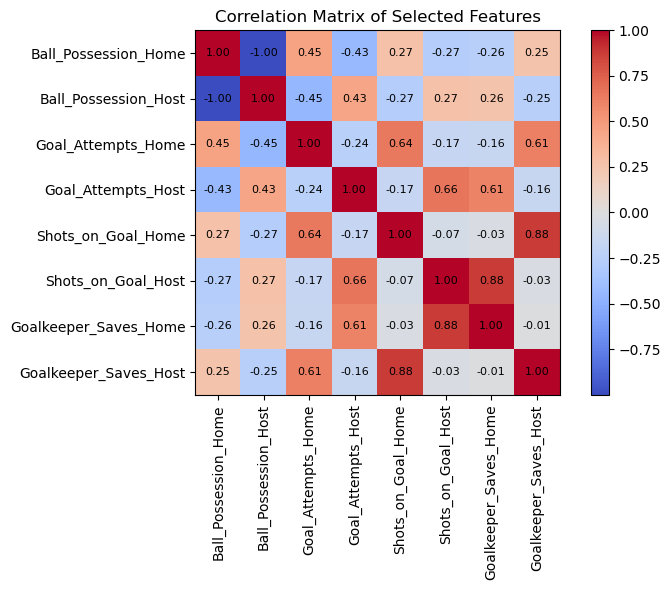

In [68]:
import matplotlib.pyplot as plt

corr = X.corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Correlation Matrix of Selected Features')

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [69]:
corr_df = X.copy()

corr_df['home_score'] = clean_df['home_score']
corr_df['away_score'] = clean_df['away_score']

In [70]:
corr = corr_df.corr()

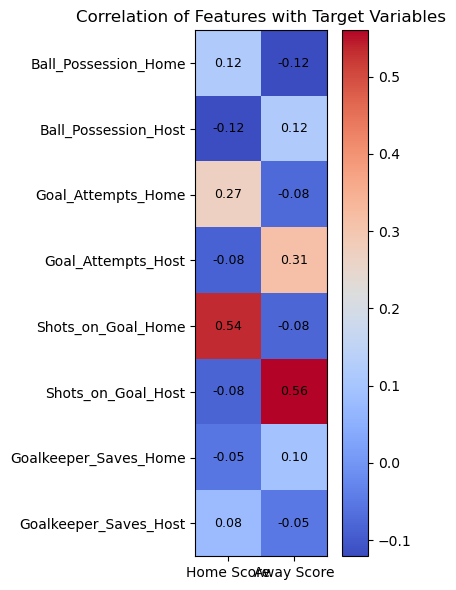

In [71]:
import matplotlib.pyplot as plt

target_corr = corr[['home_score', 'away_score']].drop(['home_score', 'away_score'])

plt.figure(figsize=(4,6))
plt.imshow(target_corr, cmap='coolwarm', interpolation='none')
plt.colorbar()

plt.xticks(range(2), ['Home Score', 'Away Score'])
plt.yticks(range(len(target_corr.index)), target_corr.index)

for i in range(len(target_corr.index)):
    for j in range(2):
        plt.text(j, i, f"{target_corr.iloc[i, j]:.2f}",
                 ha='center', va='center', fontsize=9)

plt.title("Correlation of Features with Target Variables")
plt.tight_layout()
plt.show()

## Conclusion

Model| Features Used| R2 score|
----|--------------|----|
Model 1| Possession + Goal Attempts + Shots on target + saves| 0.9886818199212615|
Model 2| Possession | 0.015142497635904473|
Model 3| Goal Attempts| 0.09415476061550437|
Model 4| Possession + Goal Attempts| 0.09450246904726062|
Model 5| Possession + Goal Attempts + Shots on Target| 0.31484384855931724|
Model 6| Goal Attempts + Shots on Target + Saves| 0.9886817378327972|
Model 7| Shots on Target + Saves| 0.9886808716821063|

#### I developed several multiple linear regression models using different combinations of in-match performance metrics. After comparing the performance of each model, I found that Ball Possession and Goal Attempts did not significantly improve the predictive performance once Shots on Target and Goalkeeper Saves were included.
#### Therefore, the final model was built using Shots on Target and Goalkeeper Saves (for both home and away teams), as these were found to be the strongest and most reliable predictors of the final match score.

# Final Programme

In [72]:
# -----------------------------
# Predict a New Match
# -----------------------------

Team_1 = input("Enter Team 1 Name: ")
Team_2 = input("Enter Team 2 Name: ")

home_shots = int(input(f"Enter {Team_1} Shots on Target: "))
away_shots = int(input(f"Enter {Team_2} Shots on Target: "))

home_saves = int(input(f"Enter {Team_1} Goalkeeper Saves: "))
away_saves = int(input(f"Enter {Team_2} Goalkeeper Saves: "))

# Create dataframe with the same feature names used for argentinatraining
new_match = pd.DataFrame({
    'Shots_on_Goal_Home': [home_shots],
    'Shots_on_Goal_Host': [away_shots],
    'Goalkeeper_Saves_Home': [home_saves],
    'Goalkeeper_Saves_Host': [away_saves]
})

# Predict the score
prediction = model.predict(new_match)

home_goals = round(prediction[0][0])
away_goals = round(prediction[0][1])

print("\n===================================")
print("       MATCH PREDICTION")
print("===================================")
print(f"{Team_1}: {home_goals}")
print(f"{Team_2}: {away_goals}")
print("-----------------------------------")

# Predict the winner
if home_goals > away_goals:
    print(f"🏆 Predicted Winner: {Team_1}")
elif away_goals > home_goals:
    print(f"🏆 Predicted Winner: {Team_2}")
else:
    print("🤝 Predicted Result: Draw")

print("\nNote:")
print("This prediction is based on full-match statistics.")

Enter Team 1 Name:  Argentina
Enter Team 2 Name:  egypt
Enter Argentina Shots on Target:  7
Enter egypt Shots on Target:  2
Enter Argentina Goalkeeper Saves:  0
Enter egypt Goalkeeper Saves:  4



       MATCH PREDICTION
Argentina: 3
egypt: 2
-----------------------------------
🏆 Predicted Winner: Argentina

Note:
This prediction is based on full-match statistics.
